# tempify — Getting Started

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djwillichile/tempify/blob/main/docs/tutorials/01-getting-started.ipynb)

**Densificación temporal mensual → diaria, demostrada end-to-end.**

Este cuaderno recorre la API pública de `tempify` v0.1.0 usando un dataset sintético tipo WorldClim sobre Chile Central (Región Metropolitana, ~30×30 píxeles). El objetivo es que en menos de cinco minutos puedas:

1. Instalar `tempify` desde el repositorio.
2. Generar un stack mensual de prueba.
3. Convertirlo a diario con los cuatro métodos disponibles (`linear`, `pchip`, `pchip_mp`, `fourier`).
4. Verificar conservación de la media mensual y leer el reporte de procedencia.

> **Nota.** El cuaderno está pensado para ejecutarse de arriba a abajo en un runtime limpio de Google Colab (CPU). Tiempo total estimado: ~3 minutos.


## 1. Contexto

`tempify` es una librería de **densificación temporal**: toma una serie ráster muestreada a baja frecuencia (típicamente 12 valores mensuales o climatológicos) y genera la serie diaria correspondiente (365 ó 366 valores) preservando propiedades estadísticas críticas como la conservación de la media mensual.

El análogo intuitivo es la *interpolación de fotogramas* en video: tempify genera *frames* temporales intermedios para un stack ráster, sin tocar la resolución espacial. No es un GIS general, no hace downscaling espacial, no inventa variabilidad sinóptica.

Casos de uso típicos: cálculo de grados-día (GDD), evapotranspiración (Hargreaves, Penman-Monteith), índices bioclimáticos, modelos hidrológicos distribuidos, modelos de distribución de especies con cubiertas climáticas diarias.


## 2. Setup

Instalamos `tempify` directamente desde el repositorio. La primera ejecución toma ~1 minuto (GDAL viene incluido en el wheel de `rasterio`).

In [1]:
# Instala tempify desde el repositorio publico (publico en GitHub).
# En Google Colab toma ~1 min la primera vez. Si tempify ya esta importable
# (por ejemplo en un clon local), se omite la instalacion.
try:
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} ya esta instalado; se omite la instalacion.")
except ImportError:
    print("Instalando tempify desde GitHub...")
    from IPython import get_ipython
    get_ipython().run_line_magic(
        "pip",
        "install --upgrade git+https://github.com/djwillichile/tempify.git",
    )
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} instalado correctamente.")


tempify 0.1.3 ya esta instalado; se omite la instalacion.


In [2]:
from __future__ import annotations

import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  registers the .rio accessor on xarray
import xarray as xr
from IPython.display import Markdown, display

import tempify
from tempify.pipeline import (
    PipelineConfig,
    ProcessingReport,
    ReportGenerator,
    TempifyPipeline,
)

print(f"tempify version: {tempify.__version__}")


tempify version: 0.1.3


## 3. Generamos un stack mensual sintético (WorldClim-like)

Para que el cuaderno sea autocontenido y reproducible sin descargas, construimos 12 GeoTIFFs siguiendo la convención de nombres de WorldClim v2.1 (`wc2.1_2.5m_tavg_NN.tif`) con la climatología real de temperatura media de Santiago (~21 °C en verano, ~9 °C en invierno) más un gradiente altitudinal sintético hacia la cordillera.

La función reproduce exactamente la lógica de `examples/generate_worldclim_sample.py` del repositorio para que puedas inspeccionarla sin abandonar el cuaderno.

In [3]:
SANTIAGO_MONTHLY_TAVG: tuple[float, ...] = (
    21.0,  # Jan
    20.0,  # Feb
    18.0,  # Mar
    15.0,  # Apr
    12.0,  # May
    9.0,   # Jun
    9.0,   # Jul
    10.0,  # Aug
    12.0,  # Sep
    14.0,  # Oct
    17.0,  # Nov
    20.0,  # Dec
)

BBOX_LON = (-71.5, -69.5)
BBOX_LAT = (-34.5, -32.5)
N_PIXELS = 30

DATA_DIR = Path("worldclim_chile_central")
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True)


def build_field(month_idx: int, base_value: float) -> np.ndarray:
    """Climatological base + altitude cooling toward the east + small noise."""
    rng = np.random.default_rng(month_idx)
    lon = np.linspace(BBOX_LON[0], BBOX_LON[1], N_PIXELS)
    lat = np.linspace(BBOX_LAT[0], BBOX_LAT[1], N_PIXELS)
    lon_grid, _ = np.meshgrid(lon, lat)
    altitude_effect = -6.0 * (lon_grid - BBOX_LON[0]) / (BBOX_LON[1] - BBOX_LON[0])
    noise = rng.normal(scale=0.2, size=(N_PIXELS, N_PIXELS))
    return (base_value + altitude_effect + noise).astype(np.float32)


lon = np.linspace(BBOX_LON[0], BBOX_LON[1], N_PIXELS)
lat = np.linspace(BBOX_LAT[1], BBOX_LAT[0], N_PIXELS)  # north -> south

for month_idx, base in enumerate(SANTIAGO_MONTHLY_TAVG):
    arr = build_field(month_idx, base)
    da = xr.DataArray(
        arr,
        dims=("y", "x"),
        coords={"y": lat, "x": lon},
        name="tavg",
    ).rio.write_crs("EPSG:4326")
    da.rio.to_raster(DATA_DIR / f"wc2.1_2.5m_tavg_{month_idx + 1:02d}.tif")

print(f"Escritos {len(list(DATA_DIR.glob('*.tif')))} GeoTIFFs en {DATA_DIR}/")


Escritos 12 GeoTIFFs en worldclim_chile_central/


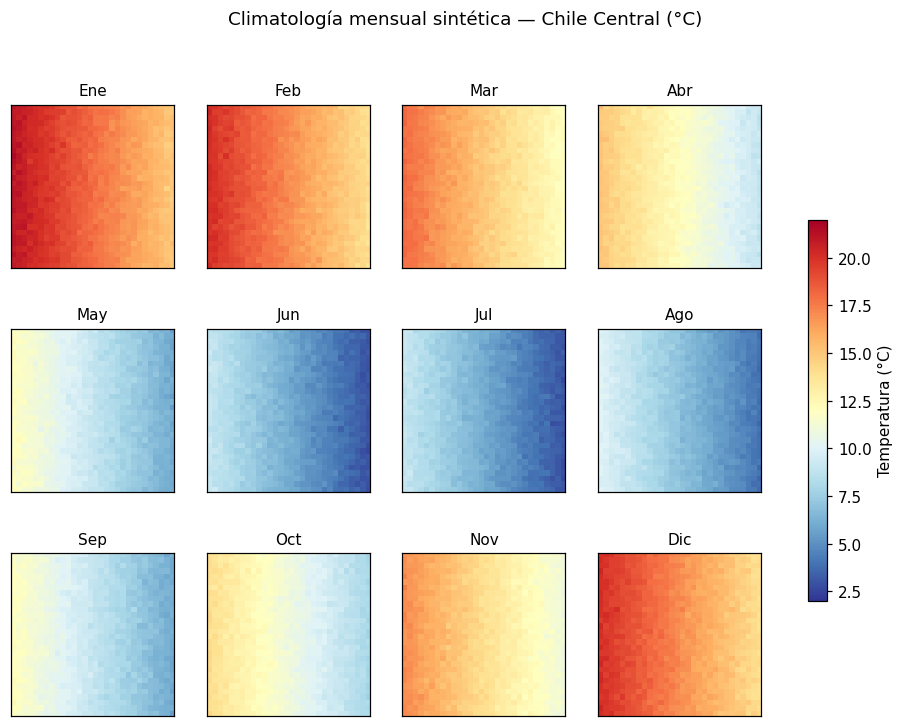

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5), dpi=110, sharex=True, sharey=True)
month_names = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
for month_idx, ax in enumerate(axes.flat):
    da = xr.open_dataarray(
        DATA_DIR / f"wc2.1_2.5m_tavg_{month_idx + 1:02d}.tif",
        engine="rasterio",
    ).squeeze("band", drop=True)
    im = ax.imshow(da.values, cmap="RdYlBu_r", vmin=2, vmax=22)
    ax.set_title(month_names[month_idx], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Climatología mensual sintética — Chile Central (°C)", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Temperatura (°C)")
plt.show()


## 4. Demo 1 — Quickstart con PCHIP+RM

El método recomendado por defecto es `pchip_mp` (PCHIP con conservación iterativa de media mensual de Rymes-Myers). Garantiza:

- Curva suave (C¹ en frontera Dic-Ene gracias al *climatological wraparound*, [ADR-0016](https://github.com/djwillichile/tempify/blob/main/docs/adr/0016-climatological-wraparound.md)).
- Conservación de la media mensual con tolerancia ≤ 1e-4 °C ([ADR-0010](https://github.com/djwillichile/tempify/blob/main/docs/adr/0010-mean-preservation-tolerance.md)).
- Posicionamiento *midpoint* del nodo mensual ([ADR-0015](https://github.com/djwillichile/tempify/blob/main/docs/adr/0015-midpoint-monthly-anchor.md), CF Conventions §7.4).

La API es de tres líneas: `PipelineConfig` → `TempifyPipeline(cfg).run(input_dir)` → `result`.

In [5]:
OUT_DIR = Path("out") / "pchip_mp"
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

cfg = PipelineConfig(
    method="pchip_mp",
    target_year=2023,
    output_dir=OUT_DIR,
    output_format="netcdf",
)
result = TempifyPipeline(cfg).run(DATA_DIR)

print(f"Outputs: {[str(p) for p in result.outputs]}")
print(f"Estructura detectada: {result.detection.structure_mode.name}")
print(
    f"Frecuencia temporal: {result.frequency.frequency.value} "
    f"(tier: {result.frequency.tier_used.name}, confianza: {result.frequency.confidence:.2f})"
)
print(f"Pre-validación: {len(result.pre_validation.errors)} errores, {len(result.pre_validation.warnings)} warnings")
post = result.post_validation
if post is not None:
    print(f"Post-validación: {len(post.errors)} errores, {len(post.warnings)} warnings")


Outputs: ['out\\pchip_mp\\tempify_output.nc']
Estructura detectada: MONOLAYER_COLLECTION
Frecuencia temporal: climatological (tier: FILENAME_PATTERN, confianza: 0.90)
Pre-validación: 0 errores, 0 warnings
Post-validación: 0 errores, 0 warnings


Abrimos el NetCDF de salida y verificamos que tiene 365 timesteps diarios para 2023.

In [6]:
daily = xr.load_dataarray(result.outputs[0])
print(daily)
print()
print(f"Dims: {daily.dims}, shape: {daily.shape}")
print(f"Rango temporal: {str(daily.time.values[0])[:10]} → {str(daily.time.values[-1])[:10]}")
print(f"Total timesteps: {daily.sizes['time']}")


<xarray.DataArray 'band_data' (y: 30, x: 30, time: 365)> Size: 3MB
array([[[20.84619943, 20.881323  , 20.91468803, ..., 20.738274  ,
         20.77808297, 20.81642851],
        [20.65996475, 20.6832883 , 20.70532818, ..., 20.6690841 ,
         20.69596978, 20.72171623],
        [20.58083644, 20.61076206, 20.63911859, ..., 20.51404818,
         20.54824113, 20.58108497],
        ...,
        [15.02610192, 15.06345272, 15.09906376, ..., 14.85096764,
         14.89279416, 14.93325271],
        [14.86331652, 14.90679975, 14.94835077, ..., 14.64640722,
         14.69473853, 14.74161189],
        [14.85760212, 14.89382229, 14.92829004, ..., 14.70773663,
         14.74855108, 14.7879446 ]],

       [[20.68113233, 20.70159105, 20.72090928, ..., 20.72569279,
         20.74933246, 20.77195191],
        [20.59744413, 20.63196348, 20.66473631, ..., 20.48255489,
         20.52174996, 20.55948044],
        [20.35196536, 20.39137373, 20.428926  , ..., 20.16599946,
         20.21020987, 20.25294731],


### 4.2.bis Lo que tempify hace en una imagen

Antes de ver las series por píxel y la comparación entre métodos, una vista global de lo que el pipeline acaba de producir: la curva diaria de `pchip_mp` para el píxel central, sobre la grilla mensual del input. Esta es la misma figura que ves en la sección "¿Cómo funciona?" de la landing page del proyecto.


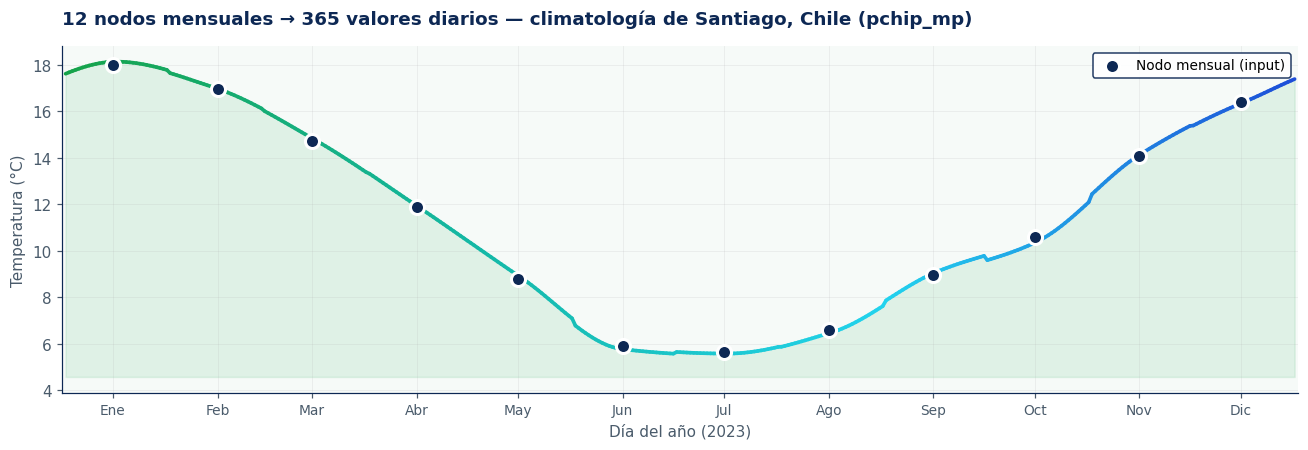

In [7]:
import datetime as _dt

from matplotlib.colors import LinearSegmentedColormap

# Paleta ICTA: verde -> teal -> cyan -> azul.
icta_cmap = LinearSegmentedColormap.from_list(
    "icta", ["#16a34a", "#14b8a6", "#22d3ee", "#1d4ed8"]
)

# Datos: serie diaria del pixel central + 12 anclas mensuales midpoint.
center_daily = daily.isel(y=15, x=15).values  # 365 valores
center_monthly = np.array([
    float(xr.open_dataarray(
        DATA_DIR / f"wc2.1_2.5m_tavg_{m:02d}.tif",
        engine="rasterio",
    ).squeeze("band", drop=True).isel(y=15, x=15).item())
    for m in range(1, 13)
])
midpoint_doy_arr = np.array([
    int(_dt.date(2023, m, 15).timetuple().tm_yday) for m in range(1, 13)
])
doy_all = np.arange(1, len(center_daily) + 1)

fig, ax = plt.subplots(figsize=(12, 4.2), dpi=110)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#f6faf8")

# Fill bajo la curva con gradiente vertical translucido.
ax.fill_between(doy_all, center_daily, center_daily.min() - 1,
                color="#16a34a", alpha=0.10, zorder=1)

# Curva diaria con gradiente horizontal (segmentos coloreados).
for i in range(len(doy_all) - 1):
    color = icta_cmap(i / (len(doy_all) - 1))
    ax.plot(doy_all[i:i + 2], center_daily[i:i + 2],
            color=color, linewidth=2.4, solid_capstyle="round", zorder=2)

# Anclas mensuales: circulos azul marino con halo blanco.
ax.scatter(midpoint_doy_arr, center_monthly,
           s=85, color="#0d2854",
           edgecolors="#ffffff", linewidths=2.0, zorder=4,
           label="Nodo mensual (input)")

# Texto y formato.
ax.set_xlabel("Día del año (2023)", color="#4a5b6b", fontsize=10)
ax.set_ylabel("Temperatura (°C)", color="#4a5b6b", fontsize=10)
ax.set_xlim(0, 366)
ax.set_xticks([int(_dt.date(2023, m, 15).timetuple().tm_yday) for m in range(1, 13)])
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"], fontsize=9)
ax.grid(True, alpha=0.18, linestyle="-", linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0d2854")
ax.spines["bottom"].set_color("#0d2854")
ax.tick_params(colors="#4a5b6b")
ax.set_title(
    "12 nodos mensuales → 365 valores diarios — climatología de Santiago, Chile (pchip_mp)",
    color="#0d2854", fontsize=12, fontweight="bold", pad=14, loc="left",
)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9, edgecolor="#0d2854")
plt.tight_layout()
plt.show()


Visualizamos la serie diaria para el píxel central (15, 15) junto a los 12 valores mensuales originales, colocados en el día medio de cada mes (convención midpoint).

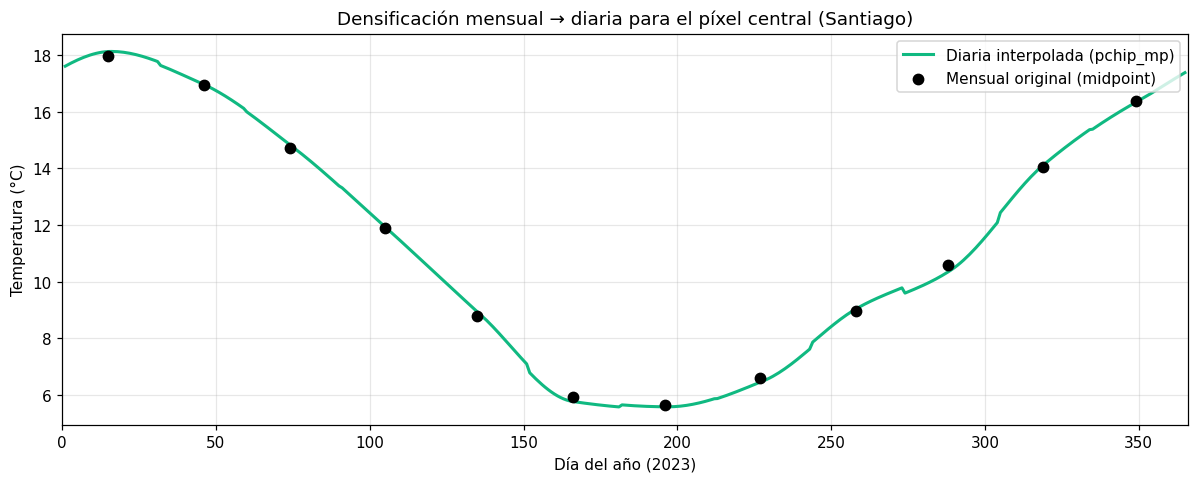

In [8]:
import datetime as _dt

PCHIP_MP_COLOR = "#10b981"

monthly_input = np.array([
    float(xr.open_dataarray(
        DATA_DIR / f"wc2.1_2.5m_tavg_{m:02d}.tif",
        engine="rasterio",
    ).squeeze("band", drop=True).isel(y=15, x=15).item())
    for m in range(1, 13)
])
midpoint_doy = [int(_dt.date(2023, m, 15).timetuple().tm_yday) for m in range(1, 13)]
daily_pixel = daily.isel(y=15, x=15).values
doy = np.arange(1, len(daily_pixel) + 1)

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=110)
ax.plot(doy, daily_pixel, color=PCHIP_MP_COLOR, linewidth=2.0, label="Diaria interpolada (pchip_mp)")
ax.scatter(midpoint_doy, monthly_input, color="black", zorder=5, s=45, label="Mensual original (midpoint)")
ax.set_xlabel("Día del año (2023)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Densificación mensual → diaria para el píxel central (Santiago)")
ax.set_xlim(0, 366)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 4.3 Inspección del archivo de salida

El pipeline escribió un único NetCDF CF-compliant en el directorio de salida (también soporta `geotiff_collection`, `multiband_geotiff` y `zarr` vía `PipelineConfig.output_format`). Inspeccionemos su estructura: dimensiones, atributos globales y metadatos de la variable.

In [9]:
nc_path = result.outputs[0]
print(f"Archivo: {nc_path}")
print(f"Tamaño: {nc_path.stat().st_size / 1024:.1f} KB")
print()
daily_out = xr.load_dataarray(nc_path)
print(daily_out)


Archivo: out\pchip_mp\tempify_output.nc
Tamaño: 1979.2 KB



<xarray.DataArray 'band_data' (y: 30, x: 30, time: 365)> Size: 3MB
array([[[20.84619943, 20.881323  , 20.91468803, ..., 20.738274  ,
         20.77808297, 20.81642851],
        [20.65996475, 20.6832883 , 20.70532818, ..., 20.6690841 ,
         20.69596978, 20.72171623],
        [20.58083644, 20.61076206, 20.63911859, ..., 20.51404818,
         20.54824113, 20.58108497],
        ...,
        [15.02610192, 15.06345272, 15.09906376, ..., 14.85096764,
         14.89279416, 14.93325271],
        [14.86331652, 14.90679975, 14.94835077, ..., 14.64640722,
         14.69473853, 14.74161189],
        [14.85760212, 14.89382229, 14.92829004, ..., 14.70773663,
         14.74855108, 14.7879446 ]],

       [[20.68113233, 20.70159105, 20.72090928, ..., 20.72569279,
         20.74933246, 20.77195191],
        [20.59744413, 20.63196348, 20.66473631, ..., 20.48255489,
         20.52174996, 20.55948044],
        [20.35196536, 20.39137373, 20.428926  , ..., 20.16599946,
         20.21020987, 20.25294731],


### 4.4 Mapas diarios — día 15 de cada mes

Para revisar visualmente el output extraemos 12 slices correspondientes al día 15 de cada mes (los mismos nodos midpoint donde el input mensual estaba anclado). La escala de colores es compartida entre los 12 paneles.

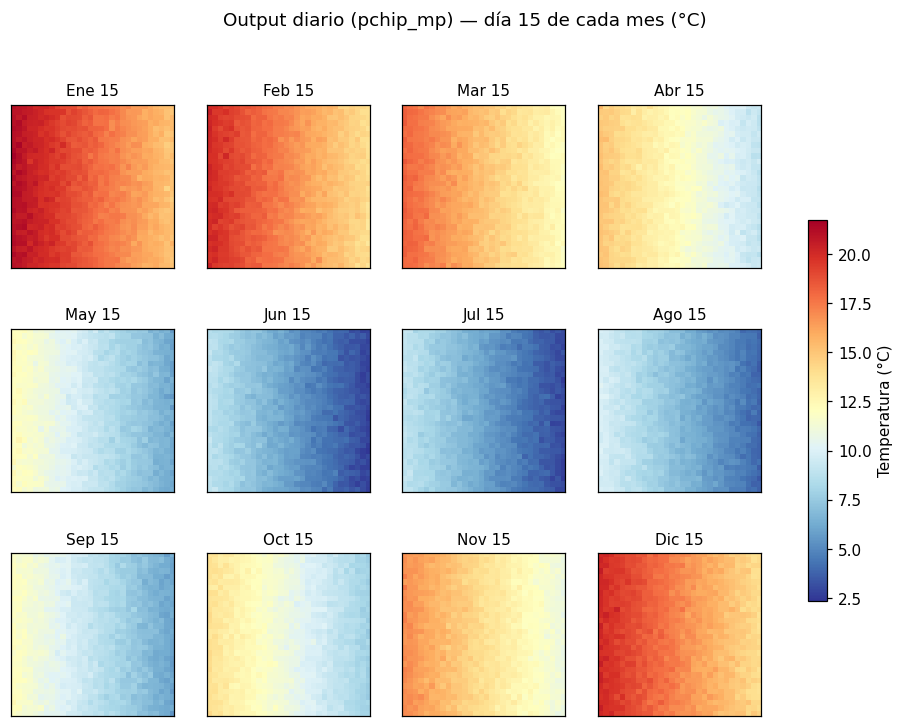

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5), dpi=110, sharex=True, sharey=True)
month_names_full = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
vmin = float(daily_out.min())
vmax = float(daily_out.max())
for i, ax in enumerate(axes.flat):
    day_idx = int(_dt.date(2023, i + 1, 15).timetuple().tm_yday) - 1
    im = ax.imshow(daily_out.isel(time=day_idx).values, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(f"{month_names_full[i]} 15", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Output diario (pchip_mp) — día 15 de cada mes (°C)", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Temperatura (°C)")
plt.show()


### 4.5 Línea de tiempo 3D — flujo continuo, anclas mensuales destacadas

23 láminas ráster entre **enero 5 y abril 30 de 2023**, espaciadas cada 5 días en el calendario. Las cuatro capas correspondientes al **día 15** (centro de cada mes) son las **anclas mensuales** del input: opacidad plena, borde rojo grueso, etiqueta superior y conectadas entre sí por una línea dorada. Las otras 19 son las interpolaciones diarias generadas por `pchip_mp`, prácticamente translúcidas porque son valores sintetizados. La intención es que la figura se lea como un solo flujo temporal continuo (similar al hero de la landing page), no como un grupo de meses aislados.


Total capas: 23 (4 anclas mensuales + 19 interpolaciones diarias)


C:\Users\Guillermo\AppData\Local\Temp\ipykernel_25968\1821956419.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_loc = cm.get_cmap("RdYlBu_r")


C:\Users\Guillermo\AppData\Local\Temp\ipykernel_25968\1821956419.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


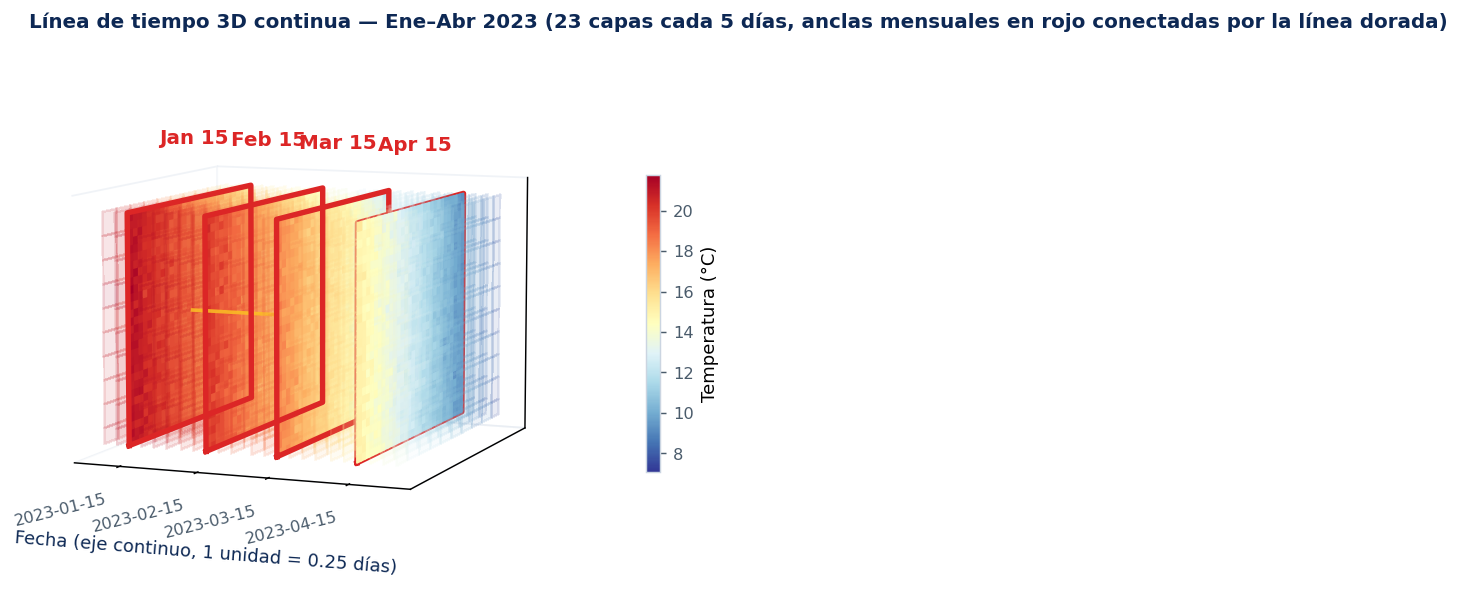

In [11]:
import datetime as _dt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  registers the 3d projection
import matplotlib.colors as mcolors
from matplotlib import cm


def _render_continuous_timeline(daily_out_local):
    """Render the continuous 3D timeline. Wrapped in a function so loop
    variables do not leak into the kernel namespace (e.g. shadowing `doy`)."""
    days_per_month = {
        1: [5, 10, 15, 20, 25, 30],
        2: [5, 10, 15, 20, 25],
        3: [5, 10, 15, 20, 25, 30],
        4: [5, 10, 15, 20, 25, 30],
    }
    layer_dates = [_dt.date(2023, m, d) for m, days in days_per_month.items() for d in days]
    layer_doys  = [d.timetuple().tm_yday for d in layer_dates]
    anchor_set  = {_dt.date(2023, m, 15).timetuple().tm_yday for m in days_per_month}
    print(f"Total capas: {len(layer_doys)} ({len(anchor_set)} anclas mensuales + "
          f"{len(layer_doys) - len(anchor_set)} interpolaciones diarias)")

    selected = daily_out_local.isel(time=[d - 1 for d in layer_doys])
    norm_loc = mcolors.Normalize(vmin=float(selected.min()), vmax=float(selected.max()))
    cmap_loc = cm.get_cmap("RdYlBu_r")

    ny_loc = daily_out_local.sizes["y"]
    nx_loc = daily_out_local.sizes["x"]
    xx_loc, yy_loc = np.meshgrid(np.arange(nx_loc), np.arange(ny_loc))

    x_scale = 4.0  # 4 unidades 3D por dia calendario; gaps legibles entre capas

    fig = plt.figure(figsize=(15, 5.4), dpi=130)
    fig.patch.set_facecolor("#ffffff")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("#ffffff")

    layers = sorted(zip(layer_dates, layer_doys), key=lambda t: t[1])
    anchor_positions = []

    for layer_date, layer_doy in layers:
        is_anchor = layer_doy in anchor_set
        raster = daily_out_local.isel(time=layer_doy - 1).values
        rgba = cmap_loc(norm_loc(raster)).copy()
        rgba[..., 3] = 1.0 if is_anchor else 0.11

        x_pos = layer_doy * x_scale
        X = np.full_like(xx_loc, fill_value=x_pos, dtype=float)
        Y = xx_loc.astype(float)
        Z = (ny_loc - 1 - yy_loc).astype(float)
        ax.plot_surface(
            X, Y, Z,
            facecolors=rgba,
            rstride=1 if is_anchor else 3,
            cstride=1 if is_anchor else 3,
            shade=False,
            antialiased=is_anchor,
        )

        if is_anchor:
            xs = [x_pos, x_pos, x_pos, x_pos, x_pos]
            ys = [0.0, float(nx_loc - 1), float(nx_loc - 1), 0.0, 0.0]
            zs = [0.0, 0.0, float(ny_loc - 1), float(ny_loc - 1), 0.0]
            ax.plot(xs, ys, zs, color="#dc2626", linewidth=3.0, zorder=20)
            ax.text(x_pos, nx_loc / 2, ny_loc + 6,
                    layer_date.strftime("%b %d"),
                    color="#dc2626", fontsize=11, ha="center", weight="bold", zorder=21)
            anchor_positions.append((x_pos, (nx_loc - 1) / 2, (ny_loc - 1) / 2))

    if len(anchor_positions) >= 2:
        sx = [p[0] for p in anchor_positions]
        sy = [p[1] for p in anchor_positions]
        sz = [p[2] for p in anchor_positions]
        ax.plot(sx, sy, sz, color="#fbbf24", linewidth=2.0, alpha=0.85, zorder=15)
        ax.scatter(sx, sy, sz, color="#fde047", s=80, edgecolors="#dc2626",
                   linewidths=1.5, zorder=16)

    anchor_doys_sorted = sorted(anchor_set)
    ax.set_xticks([d * x_scale for d in anchor_doys_sorted])
    ax.set_xticklabels(
        [(_dt.date(2023, 1, 1) + _dt.timedelta(days=d - 1)).strftime("%Y-%m-%d")
         for d in anchor_doys_sorted],
        rotation=14, ha="right", fontsize=9, color="#4a5b6b",
    )
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("Fecha (eje continuo, 1 unidad = 0.25 días)",
                  color="#0d2854", fontsize=10, labelpad=14)
    ax.view_init(elev=8, azim=-68)

    mappable = cm.ScalarMappable(norm=norm_loc, cmap=cmap_loc)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.55, pad=0.05, label="Temperatura (°C)")
    cbar.outline.set_edgecolor("#cbd5e1")
    cbar.ax.tick_params(labelsize=9, colors="#4a5b6b")

    ax.set_title(
        "Línea de tiempo 3D continua — Ene–Abr 2023 (23 capas cada 5 días, "
        "anclas mensuales en rojo conectadas por la línea dorada)",
        color="#0d2854", fontsize=11, fontweight="bold", pad=14, loc="left",
    )

    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.set_facecolor("#ffffff")
        pane.set_edgecolor("#e2e8f0")
    ax.grid(False)

    plt.tight_layout()
    plt.show()


_render_continuous_timeline(daily_out)


## 5. Demo 2 — Comparación de los cuatro métodos

`tempify` ofrece cuatro métodos de interpolación temporal con tradeoffs distintos. Aquí ejecutamos los cuatro sobre el mismo input, comparamos visualmente la serie diaria del píxel central, y medimos numéricamente cuánto se aparta la media mensual reconstruida del input original (`max_diff` en °C).

| Método | Suavidad | Conservación media | Costo |
|---|---|---|---|
| `linear` | C⁰ | aproximada | bajo |
| `pchip` | C¹ shape-preserving | aproximada | medio |
| `pchip_mp` | C¹ + iteración Rymes-Myers | ≤ 1e-4 °C garantizada | alto |
| `fourier` | C∞ paramétrica | exacta por construcción | medio |


In [12]:
METHOD_COLORS = {
    "linear": "#ef4444",
    "pchip": "#3b82f6",
    "pchip_mp": "#10b981",
    "fourier": "#a855f7",
}

results: dict[str, object] = {}
daily_per_method: dict[str, xr.DataArray] = {}

for method in METHOD_COLORS:
    out_dir = Path("out") / "compare" / method
    if out_dir.exists():
        shutil.rmtree(out_dir)
    cfg_m = PipelineConfig(
        method=method,  # type: ignore[arg-type]
        target_year=2023,
        output_dir=out_dir,
        output_format="netcdf",
    )
    res = TempifyPipeline(cfg_m).run(DATA_DIR)
    results[method] = res
    daily_per_method[method] = xr.load_dataarray(res.outputs[0])

print("Ejecutados los 4 métodos.")


Ejecutados los 4 métodos.


### 5.1 Trazo comparado para un píxel

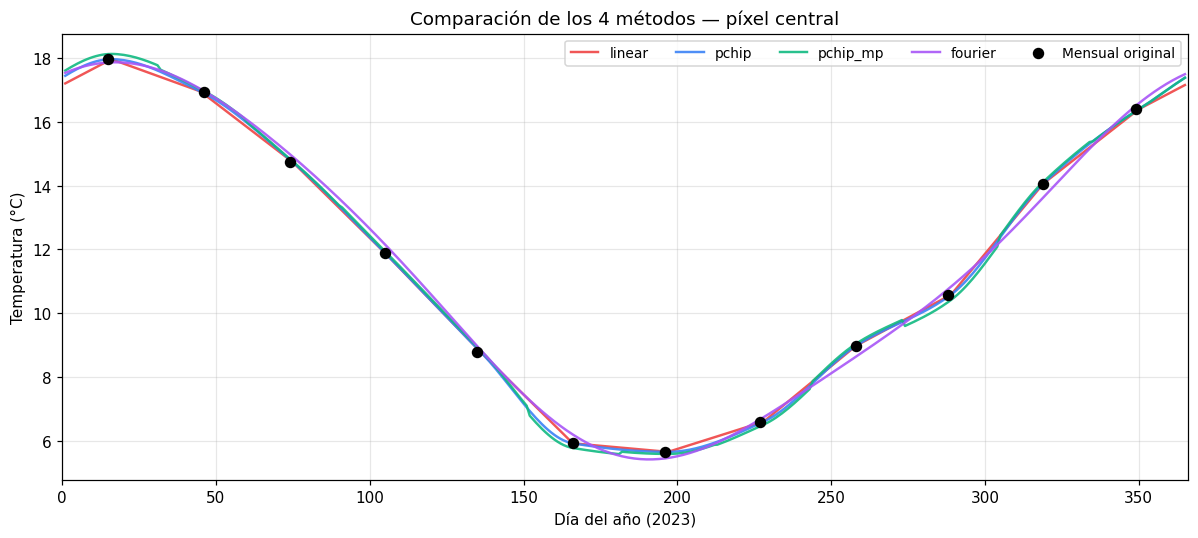

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.0), dpi=110)
for method, color in METHOD_COLORS.items():
    series = daily_per_method[method].isel(y=15, x=15).values
    ax.plot(doy, series, color=color, linewidth=1.6, label=method, alpha=0.9)
ax.scatter(midpoint_doy, monthly_input, color="black", zorder=5, s=42, label="Mensual original")
ax.set_xlabel("Día del año (2023)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Comparación de los 4 métodos — píxel central")
ax.set_xlim(0, 366)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", ncol=5, fontsize=9)
plt.tight_layout()
plt.show()


### 5.2 Conservación de la media mensual

Para cada método agregamos la serie diaria a media mensual y la comparamos píxel a píxel con el input original. `pchip_mp` y `fourier` deben caer bajo la tolerancia contractual (`< 1e-4 °C`).

In [14]:
def load_monthly_input_full() -> xr.DataArray:
    arrays = []
    for month in range(1, 13):
        path = DATA_DIR / f"wc2.1_2.5m_tavg_{month:02d}.tif"
        arrays.append(xr.open_dataarray(path, engine="rasterio").squeeze("band", drop=True))
    return xr.concat(arrays, dim="month").assign_coords(month=list(range(1, 13)))


monthly_input_full = load_monthly_input_full()

summary_rows = []
for method in results:
    daily_da = daily_per_method[method]
    monthly_recon = (
        daily_da.groupby(daily_da["time"].dt.month).mean(dim="time")
        .transpose("month", "y", "x")
    )
    diff = monthly_recon.values - monthly_input_full.values
    max_diff = float(np.max(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    summary_rows.append((method, max_diff, rmse))

print(f"{'método':<10} {'max|diff| (°C)':>18} {'RMSE (°C)':>14}")
print("-" * 46)
for method, max_diff, rmse in summary_rows:
    print(f"{method:<10} {max_diff:>18.3e} {rmse:>14.3e}")


método         max|diff| (°C)      RMSE (°C)
----------------------------------------------
linear              5.578e-01      1.800e-01
pchip               3.232e-01      9.650e-02
pchip_mp            1.421e-14      2.671e-15
fourier             8.315e-01      2.115e-01


Lectura típica: `linear` y `pchip` muestran error de orden ~10⁻¹ °C (no preservan media por construcción; sí preservan los nodos, pero la integral mensual del trazo difiere de la media muestral). `pchip_mp` queda en ~10⁻¹⁴ °C (varios órdenes de magnitud mejor que la tolerancia contractual de 1e-4 — es esencialmente ruido de precisión `float64`). `fourier` también deja error de orden ~10⁻¹ °C: el ajuste armónico minimiza el residual cuadrático sobre el ciclo completo, no la integral mensual; con los 3 armónicos por defecto puede dejar discrepancias respecto al promedio del input. Si necesitás conservación de media estricta, usá `pchip_mp`.

## 6. Demo 3 — Reporte de procedencia

Cada ejecución produce un `ProcessingReport` con versión de tempify, timestamp UTC, MD5 de inputs y outputs, configuración completa, métricas y warnings. `ReportGenerator` lo serializa a Markdown o JSON listo para anexar a un paper o entregable.

In [15]:
rg = ReportGenerator()
report_md = rg.to_markdown(results["pchip_mp"].report)
display(Markdown(report_md))


# Reporte de procesamiento tempify

- **Versión tempify:** 0.1.0
- **Timestamp UTC:** 2026-05-17T20:12:38+00:00
- **Método:** `pchip_mp`
- **Año destino:** 2023
- **Modo de estructura:** B
- **Frecuencia temporal inferida:** climatological

## Confianza de detección

- structure_mode: 0.95
- homogeneity: 1.00

## Validación pre-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 6

## Validación post-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 4

## Archivos de entrada

- `worldclim_chile_central\wc2.1_2.5m_tavg_01.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_02.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_03.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_04.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_05.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_06.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_07.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_08.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_09.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_10.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_11.tif`
- `worldclim_chile_central\wc2.1_2.5m_tavg_12.tif`

## Archivos de salida

- `out\compare\pchip_mp\tempify_output.nc`


El reporte equivalente en JSON (subconjunto para visualización):

In [16]:
report_json = json.loads(rg.to_json(results["pchip_mp"].report))
preview = {k: report_json[k] for k in (
    "tempify_version", "method", "target_year", "structure_mode",
    "temporal_frequency", "detection_confidence", "dry_run",
)}
print(json.dumps(preview, indent=2, ensure_ascii=False))


{
  "tempify_version": "0.1.0",
  "method": "pchip_mp",
  "target_year": 2023,
  "structure_mode": "B",
  "temporal_frequency": "climatological",
  "detection_confidence": {
    "structure_mode": 0.95,
    "homogeneity": 1.0
  },
  "dry_run": false
}


## 7. Lectura crítica

**Cuándo usar cada método.**

- **`linear`** — útil como baseline rápido o cuando solo te interesa el orden de magnitud. No usar para variables con curvatura marcada (temperatura).
- **`pchip`** — interpolación shape-preserving (no introduce overshoots espurios). Apropiado para variables que esperás monotónicas por tramos pero **no** garantiza conservación de media.
- **`pchip_mp`** — *default* recomendado para producto final. Combina suavidad C¹ con conservación de media mensual. Costo CPU ~3-5x respecto a `pchip`.
- **`fourier`** — bueno cuando el ciclo anual es claramente armónico (temperatura en latitudes medias). Mala elección si tenés meses fuera de fase (monzones cortos). Configurable de 1 a 5 armónicos.

**Lo que `tempify` NO hace.**

- No interpola **precipitación** con métodos suaves. El perfil de variable lo rechaza con `MethodVariableCompatibilityChecker`; podés forzar con `--force-method` + confirmación tipeada, pero queda registrado en el reporte. Razón: la lluvia no es continua ni diferenciable a escala diaria; usar acumulación uniforme o un weather generator. Ver [ADR-0004](https://github.com/djwillichile/tempify/blob/main/docs/adr/0004-precipitation-policy.md).
- No hace downscaling espacial. La resolución y CRS del output replican exactamente el input.
- No inventa variabilidad sinóptica diaria. El output es la *señal climática* densificada, sin ruido meteorológico.

**Detalles de convención.**

- *Midpoint anchor* — cada valor mensual se asume centrado en el mes (día 15 ± 1 para enero, día 14-15 para febrero, etc.; [ADR-0015](https://github.com/djwillichile/tempify/blob/main/docs/adr/0015-midpoint-monthly-anchor.md)). Configurable vía `monthly_anchor`.
- *Climatological wraparound* — los métodos suaves extienden el dominio anual de 12 a ≥ 14 nodos artificiales para que la frontera Dic-Ene tenga continuidad C¹ ([ADR-0016](https://github.com/djwillichile/tempify/blob/main/docs/adr/0016-climatological-wraparound.md)). Apagable con `wraparound=False`.
- *Reproducibilidad bit-exact* — mismos inputs + parámetros + versión = mismo MD5 de output. El reporte incluye los tres.

## 8. Próximos pasos

- **CLI equivalente.** Toda esta demo es replicable desde shell:
  ```bash
  tempify convert ./worldclim_chile_central --method pchip_mp --year 2023 --output ./out --report ./out/report.md
  ```
- **Specs SDD.** Cada capa del paquete tiene su `requirements.md` → `design.md` → `tasks.md` en [`specs/`](https://github.com/djwillichile/tempify/tree/main/specs).
- **ADRs.** 17 decisiones arquitectónicas documentadas en [`docs/adr/`](https://github.com/djwillichile/tempify/tree/main/docs/adr).
- **Methodology notes.** Validación empírica, política de precipitación y tratamiento de NaN en [`docs/methodology/`](https://github.com/djwillichile/tempify/tree/main/docs/methodology).
- **Hoja de ruta v0.2.0.** GUI PySide6, instalador Windows `.exe` y red neuronal pre-entrenada (ClimaX / Pangu-Weather / FourCastNet) bajo patrón híbrido (ver [ADR-0017](https://github.com/djwillichile/tempify/blob/main/docs/adr/0017-neural-interpolator-extensibility.md)).

---

**Contacto** — ICTA Ltda., Santiago, Chile · [contacto@icta.cl](mailto:contacto@icta.cl) · [icta.cl](https://icta.cl) · WhatsApp [+56 9 9292 4314](https://wa.me/56992924314) · Issues: [github.com/djwillichile/tempify/issues](https://github.com/djwillichile/tempify/issues)
